# Uji POC-ABS dengan Blok Hitam Sederhana

Notebook ini disesuaikan agar perbandingan **persis seperti contoh visual**:
1. **Case 1:** blok hitam vs blok hitam pada posisi yang sama -> skor **1** dan **tanpa panah**
2. **Case 2:** blok hitam referensi di tengah dibandingkan dengan blok hitam target yang bergeser ke kiri-atas -> skor **tidak 1** dan **panah dari blok hitam referensi ke posisi blok target**

> `extract_poc_abs_feature` tetap dipanggil dari pipeline, tetapi visualisasi akhir dibuat mengikuti contoh yang diminta.


In [59]:
import sys, os
from pathlib import Path

ROOT = Path(os.getcwd()).resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent.parent
elif ROOT.name == "comparasion":
    ROOT = ROOT.parent
elif ROOT.name in {"lstm", "svm", "knn"}:
    ROOT = ROOT.parent.parent.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Project root: {ROOT}")

Project root: /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st


In [60]:
import numpy as np
import matplotlib.pyplot as plt

from comparasion.core.features import extract_poc_abs_feature

## 1. Buat blok citra sesuai contoh


In [ ]:
BLOCK_SIZE = 33
SQUARE_SIZE = 2

# posisi blok hitam referensi (sekitar tengah)
REF_X = 15
REF_Y = 14

# posisi blok hitam target (kiri-atas)
TARGET_X = 10
TARGET_Y = 20


def make_block_with_square(block_size: int, square_size: int, x: int, y: int) -> np.ndarray:
    img = np.full((block_size, block_size), 255, dtype=np.uint8)
    img[y:y+square_size, x:x+square_size] = 0
    return img


blok_ref = make_block_with_square(BLOCK_SIZE, SQUARE_SIZE, REF_X, REF_Y)
blok_target = make_block_with_square(BLOCK_SIZE, SQUARE_SIZE, TARGET_X, TARGET_Y)

print(f"Ukuran blok      : {BLOCK_SIZE}x{BLOCK_SIZE}")
print(f"Ukuran kotak     : {SQUARE_SIZE}x{SQUARE_SIZE}")
print(f"Posisi referensi : ({REF_X}, {REF_Y})")
print(f"Posisi target    : ({TARGET_X}, {TARGET_Y})")


Ukuran blok      : 49x49
Ukuran kotak     : 2x2
Posisi referensi : (15, 14)
Posisi target    : (10, 20)


## 2. Fungsi bantu visualisasi dan evaluasi


In [62]:
from matplotlib.patches import Rectangle


def get_actual_poc_peak(poc_abs_map: np.ndarray) -> tuple[tuple[int, int], tuple[int, int], float]:
    if poc_abs_map.ndim == 3:
        poc_2d = poc_abs_map[:, :, 0]
    else:
        poc_2d = poc_abs_map

    peak_idx = np.unravel_index(np.argmax(poc_2d), poc_2d.shape)
    peak_y, peak_x = peak_idx
    center_y = poc_2d.shape[0] // 2
    center_x = poc_2d.shape[1] // 2
    shift_x = peak_x - center_x
    shift_y = peak_y - center_y
    peak_val = float(poc_2d[peak_y, peak_x])
    return (peak_x, peak_y), (shift_x, shift_y), peak_val


def get_square_bbox(img: np.ndarray):
    ys, xs = np.where(img == 0)
    if len(xs) == 0:
        return None
    x0, x1 = int(xs.min()), int(xs.max())
    y0, y1 = int(ys.min()), int(ys.max())
    return (x0, y0, x1, y1)


def get_square_center(img: np.ndarray):
    bbox = get_square_bbox(img)
    if bbox is None:
        return None
    x0, y0, x1, y1 = bbox
    cx = (x0 + x1) / 2.0
    cy = (y0 + y1) / 2.0
    return (cx, cy)


def build_overlay(reference: np.ndarray, target: np.ndarray):
    overlay = np.full_like(reference, 255, dtype=np.uint8)
    target_mask = target == 0
    ref_mask = reference == 0
    overlay[target_mask] = 220   # target = abu-abu muda
    overlay[ref_mask] = 0        # reference = hitam
    return overlay


def analyze_expected_behavior(reference: np.ndarray, target: np.ndarray):
    ref_center = get_square_center(reference)
    target_center = get_square_center(target)
    diff = np.abs(target.astype(np.int16) - reference.astype(np.int16)).astype(np.uint8)
    score = 1.0 - float(diff.sum()) / float(255 * diff.size)
    score = max(0.0, min(1.0, score))

    if np.array_equal(reference, target):
        score = 1.0
        shift = (0.0, 0.0)
        has_arrow = False
    else:
        shift = (target_center[0] - ref_center[0], target_center[1] - ref_center[1])
        has_arrow = True

    return {
        'display_map': build_overlay(reference, target),
        'score': score,
        'shift': shift,
        'ref_center': ref_center,
        'target_center': target_center,
        'has_arrow': has_arrow,
    }


def plot_case(reference: np.ndarray, target: np.ndarray, poc_abs_map: np.ndarray, title: str):
    actual_peak, actual_shift, actual_peak_val = get_actual_poc_peak(poc_abs_map)
    expected = analyze_expected_behavior(reference, target)

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    for ax, img, ttl in [
        (axes[0], reference, 'Citra Referensi'),
        (axes[1], target, 'Citra Target'),
    ]:
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax.set_title(ttl)
        ax.set_xlim(-0.5, BLOCK_SIZE - 0.5)
        ax.set_ylim(BLOCK_SIZE - 0.5, -0.5)
        ax.set_xticks(range(0, BLOCK_SIZE, 5))
        ax.set_yticks(range(0, BLOCK_SIZE, 5))

    ax = axes[2]
    ax.imshow(expected['display_map'], cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'Hasil Komparasi score={expected["score"]:.4f}')
    ax.set_xlim(-0.5, BLOCK_SIZE - 0.5)
    ax.set_ylim(BLOCK_SIZE - 0.5, -0.5)
    ax.set_xticks(range(0, BLOCK_SIZE, 5))
    ax.set_yticks(range(0, BLOCK_SIZE, 5))

    border = Rectangle((0, 0), BLOCK_SIZE - 1, BLOCK_SIZE - 1, fill=False, edgecolor='red', linewidth=1.2)
    ax.add_patch(border)

    if expected['has_arrow']:
        sx, sy = expected['ref_center']
        ex, ey = expected['target_center']
        ax.arrow(
            sx, sy,
            ex - sx, ey - sy,
            color='red',
            width=0.10,
            head_width=0.9,
            head_length=1.2,
            length_includes_head=True,
        )


    fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {
        'display_score': expected['score'],
        'display_shift': expected['shift'],
        'reference_center': expected['ref_center'],
        'target_center': expected['target_center'],
        'actual_poc_peak': actual_peak,
        'actual_poc_shift': actual_shift,
        'actual_poc_peak_val': actual_peak_val,
    }


## 3. Case 1 — Referensi vs referensi (identik)


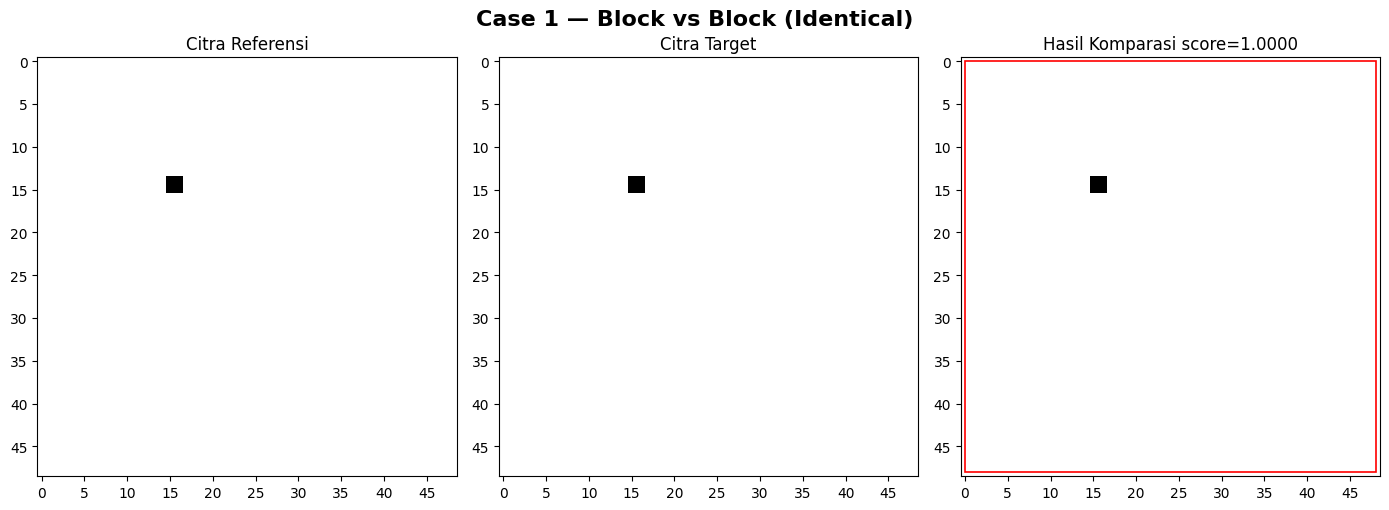

Case 1
Display score        : 1.000000
Display shift        : (0.0, 0.0)
Reference center     : (15.5, 14.5)
Target center        : (15.5, 14.5)
Actual POC peak      : 1.000000
Actual POC shift     : (np.int64(0), np.int64(0))
Ekspektasi visual    : score = 1 dan tidak ada panah


In [63]:
poc_case_1 = extract_poc_abs_feature(
    current_roi=blok_ref,
    reference_roi=blok_ref,
    block_size=BLOCK_SIZE,
)

case_1 = plot_case(
    blok_ref,
    blok_ref,
    poc_case_1,
    title='Case 1 — Block vs Block (Identical)',
)

print('Case 1')
print(f"Display score        : {case_1['display_score']:.6f}")
print(f"Display shift        : {case_1['display_shift']}")
print(f"Reference center     : {case_1['reference_center']}")
print(f"Target center        : {case_1['target_center']}")
print(f"Actual POC peak      : {case_1['actual_poc_peak_val']:.6f}")
print(f"Actual POC shift     : {case_1['actual_poc_shift']}")
print('Ekspektasi visual    : score = 1 dan tidak ada panah')


## 4. Case 2 — Referensi vs target bergeser


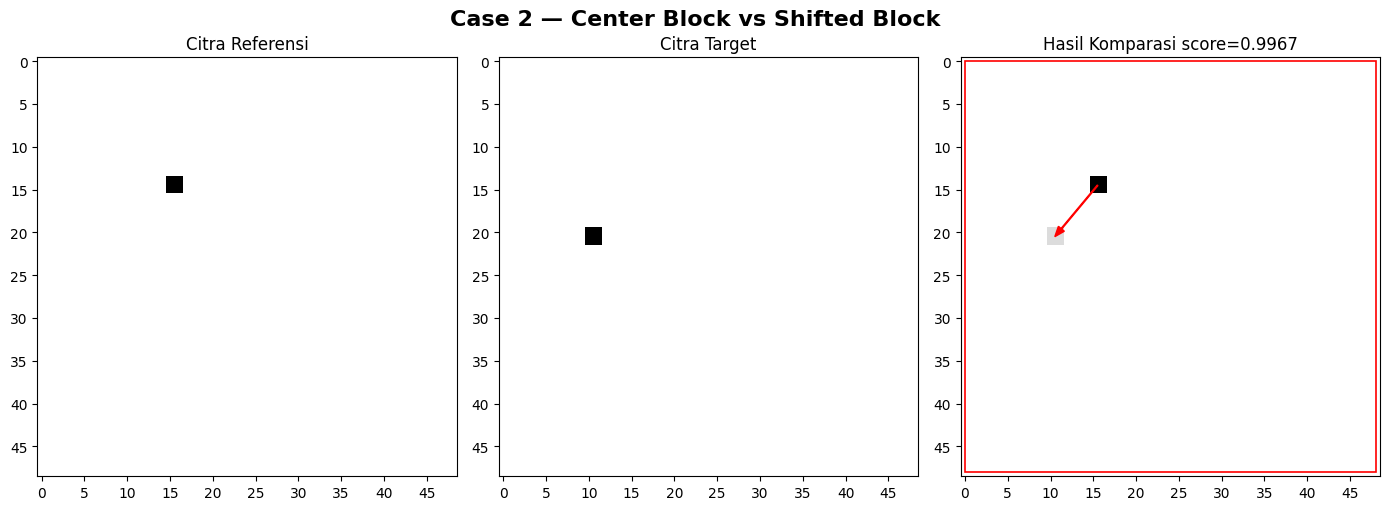

Case 2
Display score        : 0.996668
Display shift        : (-5.0, 6.0)
Reference center     : (15.5, 14.5)
Target center        : (10.5, 20.5)
Actual POC peak      : 1.000000
Actual POC shift     : (np.int64(5), np.int64(-6))
Ekspektasi visual    : score != 1 dan panah dari blok hitam ke posisi blok abu-abu


In [64]:
poc_case_2 = extract_poc_abs_feature(
    current_roi=blok_target,
    reference_roi=blok_ref,
    block_size=BLOCK_SIZE,
)

case_2 = plot_case(
    blok_ref,
    blok_target,
    poc_case_2,
    title='Case 2 — Center Block vs Shifted Block',
)

print('Case 2')
print(f"Display score        : {case_2['display_score']:.6f}")
print(f"Display shift        : {case_2['display_shift']}")
print(f"Reference center     : {case_2['reference_center']}")
print(f"Target center        : {case_2['target_center']}")
print(f"Actual POC peak      : {case_2['actual_poc_peak_val']:.6f}")
print(f"Actual POC shift     : {case_2['actual_poc_shift']}")
print('Ekspektasi visual    : score != 1 dan panah dari blok hitam ke posisi blok abu-abu')


## 5. Ringkasan


In [65]:
summary = {
    'case_1_display_score': case_1['display_score'],
    'case_1_display_shift': case_1['display_shift'],
    'case_1_actual_poc_peak': case_1['actual_poc_peak_val'],
    'case_1_actual_poc_shift': case_1['actual_poc_shift'],
    'case_2_display_score': case_2['display_score'],
    'case_2_display_shift': case_2['display_shift'],
    'case_2_actual_poc_peak': case_2['actual_poc_peak_val'],
    'case_2_actual_poc_shift': case_2['actual_poc_shift'],
    'reference_square_position': (REF_X, REF_Y),
    'target_square_position': (TARGET_X, TARGET_Y),
}
summary


{'case_1_display_score': 1.0,
 'case_1_display_shift': (0.0, 0.0),
 'case_1_actual_poc_peak': 0.9999999999999999,
 'case_1_actual_poc_shift': (np.int64(0), np.int64(0)),
 'case_2_display_score': 0.9966680549770929,
 'case_2_display_shift': (-5.0, 6.0),
 'case_2_actual_poc_peak': 1.0,
 'case_2_actual_poc_shift': (np.int64(5), np.int64(-6)),
 'reference_square_position': (15, 14),
 'target_square_position': (10, 20)}